# COMET QE vs Similarity Score Correlations
Two analyses:
1. Roundtrip BGE similarity vs Gemma COMET score — sanity check that roundtrip and COMET-KIWI agree for the Gemma translation
2. Looking at cutoff points that might indicate misalignment for human translations

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt


In [3]:
mydata_direct  = Path("par3_cometqe_scores_colnames_fixed")

sourceCols= ["gt_para", "gemma_para", "translator_1_para", "translator_2_para",
           "translator_3_para", "translator_4_para", "translator_5_para"]

In [4]:
flat_parts = []
rt_parts = []

for path in sorted(mydata_direct.glob("*.csv")):
    df = pd.read_csv(path).rename(columns={"Book_id": "book_id"})
    df["book_id"] = df["book_id"].astype(str)

    for source in sourceCols:
        comet_col = f"comet_score_{source}"
        bge_col = f"sim_score_{source}_bge"
        if comet_col in df.columns and bge_col in df.columns:
            flat_parts.append(pd.DataFrame({
                "book_id": df["book_id"],
                "paragraph_id": df["paragraph_id"],
                "source": source,
                "comet_score": df[comet_col],
                "sim_bge": df[bge_col],
            }))

    if {"comet_score_gemma_para", "sim_score_roundtrip_bge"}.issubset(df.columns):
        rt_parts.append(pd.DataFrame({
            "book_id": df["book_id"],
            "paragraph_id": df["paragraph_id"],
            "comet_gemma": df["comet_score_gemma_para"],
            "rt_sim_bge": df["sim_score_roundtrip_bge"],
        }))

flat = pd.concat(flat_parts, ignore_index=True).dropna(subset=["sim_bge"])
rt_flat = pd.concat(rt_parts, ignore_index=True).dropna(subset=["comet_gemma", "rt_sim_bge"])

print(f"BGE rows: {len(flat):,}")
print(f"Roundtrip rows: {len(rt_flat):,}")

BGE rows: 526,098
Roundtrip rows: 122,777


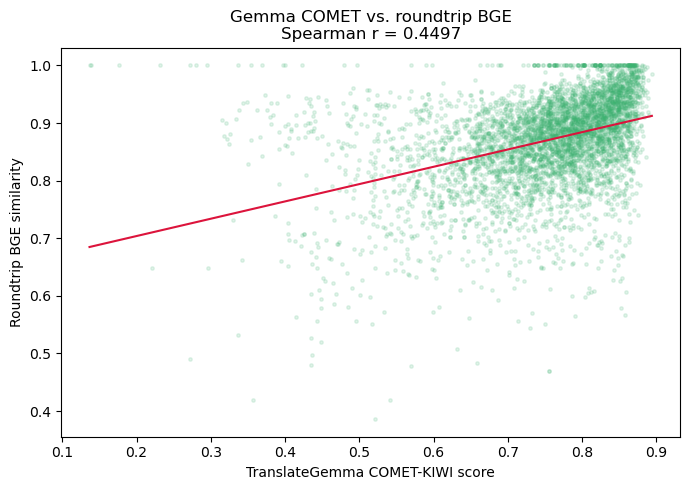

In [13]:
r, p = stats.spearmanr(rt_flat["comet_gemma"], rt_flat["rt_sim_bge"])
sample = rt_flat.sample(min(5000, len(rt_flat)), random_state=93)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["comet_gemma"], sample["rt_sim_bge"], alpha=0.15, s=6, c="mediumseagreen")

m, b = np.polyfit(sample["comet_gemma"], sample["rt_sim_bge"], 1)
xs = np.linspace(sample["comet_gemma"].min(), sample["comet_gemma"].max(), 100)
ax.plot(xs, m * xs + b, color="crimson",lw=1.5)

ax.set_xlabel("TranslateGemma COMET-KIWI score")
ax.set_ylabel("Roundtrip BGE similarity")
ax.set_title(f"Gemma COMET vs. roundtrip BGE\nSpearman r = {r:.4f}")
plt.tight_layout()
#plt.savefig("roundtrip_bge_vs_gemma_comet_scatter.png", dpi=150)
plt.show()

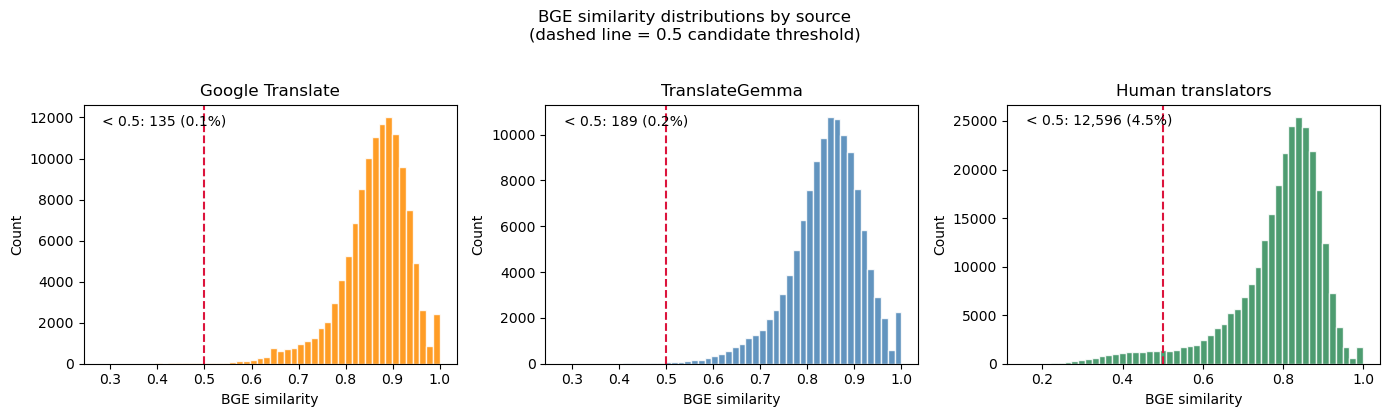

In [19]:
names_for_display = {
    "gt_para": "Google Translate",
    "gemma_para": "TranslateGemma",
    "human": "Human translators",
}

colors = {
    "gt_para": "darkorange",
    "gemma_para": "steelblue",
    "human": "seagreen",
}

human_sources = [s for s in sourceCols if s.startswith("translator_")]

flat_grouped = pd.concat([
    flat[flat["source"].isin(["gt_para", "gemma_para"])],
    flat[flat["source"].isin(human_sources)].assign(source="human"),
], ignore_index=True)

plot_sources = ["gt_para", "gemma_para", "human"]
cutoff = 0.50

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, source in zip(axes, plot_sources):
    scores = flat_grouped.loc[flat_grouped["source"] == source, "sim_bge"].dropna()
    below = (scores < cutoff).sum()
    pct = 100 * below / len(scores)

    ax.hist(
        scores, 
        bins=50,
        color=colors[source],
        edgecolor="white", 
        alpha=0.85
    )
    ax.axvline(cutoff, color="crimson", lw=1.5, linestyle="--")
    ax.set_title(names_for_display[source])
    ax.set_xlabel("BGE similarity")
    ax.set_ylabel("Count")
    ax.text(0.05, 0.92, f"< {cutoff}: {below:,} ({pct:.1f}%)", transform=ax.transAxes)

fig.suptitle("BGE similarity distributions by source\n(dashed line = 0.5 candidate threshold)", y=1.03)
plt.tight_layout()
#plt.savefig("bge_similarity_distributions_by_source.png", dpi=150)
plt.show()

In [15]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
rows = []

for source in plot_sources:
    scores = flat_grouped.loc[flat_grouped["source"] == source, "sim_bge"].dropna()
    row = {"source": names_for_display[source], "n": len(scores)}
    for threshold in thresholds:
        row[f"pct_below_{threshold:.2f}"] = round(100 * (scores < threshold).mean(), 2)
    rows.append(row)

threshold_df = pd.DataFrame(rows)
threshold_df

,source,n,pct_below_0.30,pct_below_0.40,pct_below_0.50,pct_below_0.60,pct_below_0.70
0,Google Translate,122777,0.00,0.02,0.11,0.54,3.58
1,TranslateGemma,122777,0.00,0.02,0.15,0.97,5.42
2,Human translators,280544,0.27,1.86,4.49,7.98,16.94
